<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/ClinVar-Missense-Variant-Classifier/blob/main/ClinVar_Missense_Variant_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load data
df = pd.read_csv('clinvar_missense.csv')

# 2. Basic Cleaning: Drop rows with missing critical labels
df = df.dropna(subset=['ClinicalSignificance'])

# 3. Encode Categorical Data
# Convert target to numerical (e.g., 'Pathogenic' -> 1, 'Benign' -> 0)
le = LabelEncoder()
df['target'] = le.fit_transform(df['ClinicalSignificance'])

# Select features (you may need to drop IDs and keep biological predictors)
features = ['GeneID', 'NumberSubmitters'] # Add other relevant numeric columns here
X = df[features]
y = df['target']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# 5. Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check accuracy
print(f"Model Accuracy: {model.score(X_test, y_test):.2f}")

Model Accuracy: 0.52


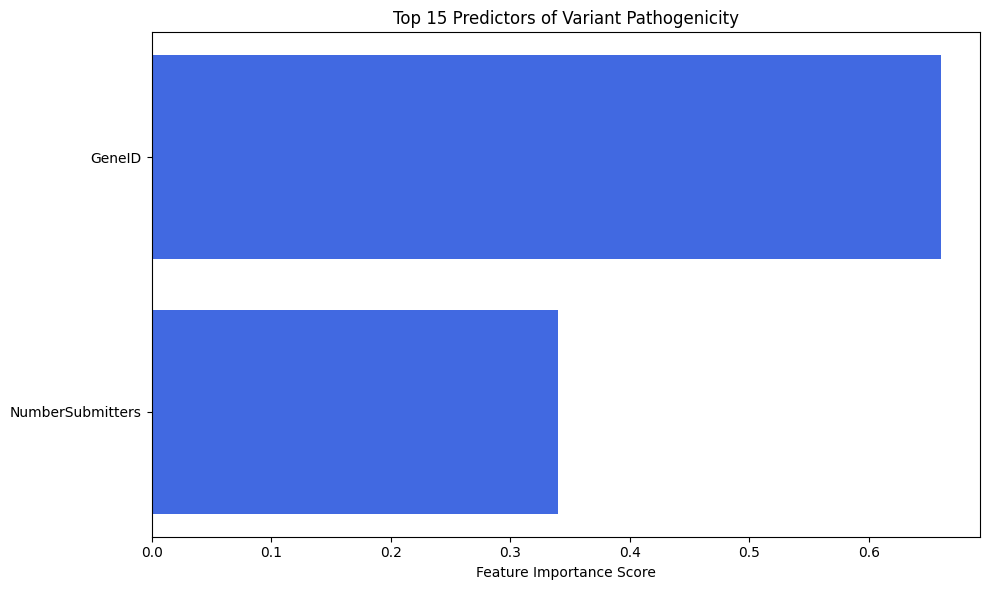

In [15]:
import matplotlib.pyplot as plt

# 6. Extract and organize importance
importances = model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 7. Plot only the Top 15
top_15 = feat_imp_df.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'], top_15['Importance'], color='royalblue')
plt.title('Top 15 Predictors of Variant Pathogenicity')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.56      0.52      0.54       182
           1       0.00      0.00      0.00         1
           2       0.34      0.32      0.33       130
           3       0.56      0.71      0.63       295
           4       0.52      0.43      0.47       302

    accuracy                           0.52       910
   macro avg       0.40      0.40      0.39       910
weighted avg       0.52      0.52      0.51       910



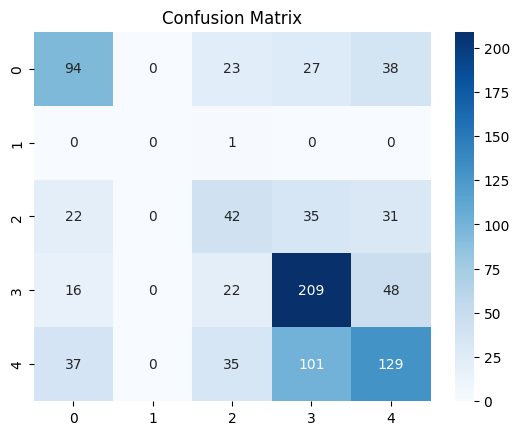

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Make predictions
y_pred = model.predict(X_test)

# Print detailed evaluation
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [17]:
model = RandomForestClassifier(class_weight='balanced', n_estimators=100)

In [18]:
# Check unique labels and their distribution
print(df['ClinicalSignificance'].value_counts())

# If there is a class with very few samples,
# explicitly drop it or combine it with a larger class.

ClinicalSignificance
Likely pathogenic       1652
Pathogenic              1440
Benign                   854
Likely benign            600
Benign/Likely benign       1
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid, cv=3)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [20]:
# 1. Initialize the optimized model
optimized_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=20,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)

# 2. Train the model
optimized_model.fit(X_train, y_train)

# 3. Predict and evaluate
from sklearn.metrics import classification_report, confusion_matrix
y_pred = optimized_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.59      0.58       182
           1       0.00      0.00      0.00         1
           2       0.33      0.45      0.38       130
           3       0.59      0.64      0.62       295
           4       0.56      0.42      0.48       302

    accuracy                           0.53       910
   macro avg       0.41      0.42      0.41       910
weighted avg       0.54      0.53      0.53       910



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# Assuming 'df' is your original dataframe
def group_labels(label):
    if label in [0, 1]: return 0    # Benign
    elif label == 2: return 1       # Uncertain
    else: return 2                  # Pathogenic

df['target_grouped'] = df['target'].apply(group_labels)
y = df['target_grouped']

# Re-run your train_test_split and model training with this new 'y'

In [22]:
from sklearn.model_selection import train_test_split

# Use the new grouped target
y = df['target_grouped']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize with your best parameters
final_model = RandomForestClassifier(
    class_weight='balanced',
    max_depth=20,
    min_samples_split=5,
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, random_state=42)

              precision    recall  f1-score   support

           0       0.56      0.63      0.59       183
           1       0.34      0.46      0.39       130
           2       0.84      0.75      0.79       597

    accuracy                           0.68       910
   macro avg       0.58      0.61      0.59       910
weighted avg       0.71      0.68      0.69       910



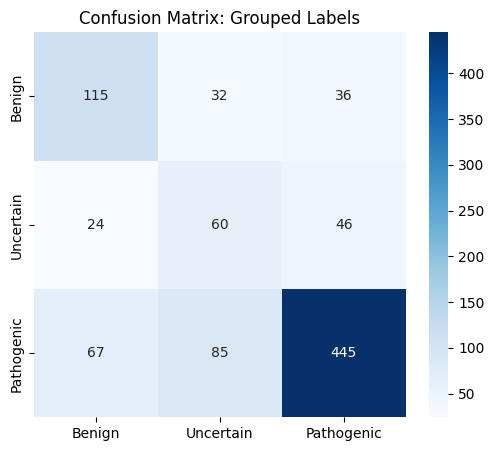

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = final_model.predict(X_test)

# 1. Classification Report
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Uncertain', 'Pathogenic'],
            yticklabels=['Benign', 'Uncertain', 'Pathogenic'])
plt.title('Confusion Matrix: Grouped Labels')
plt.show()

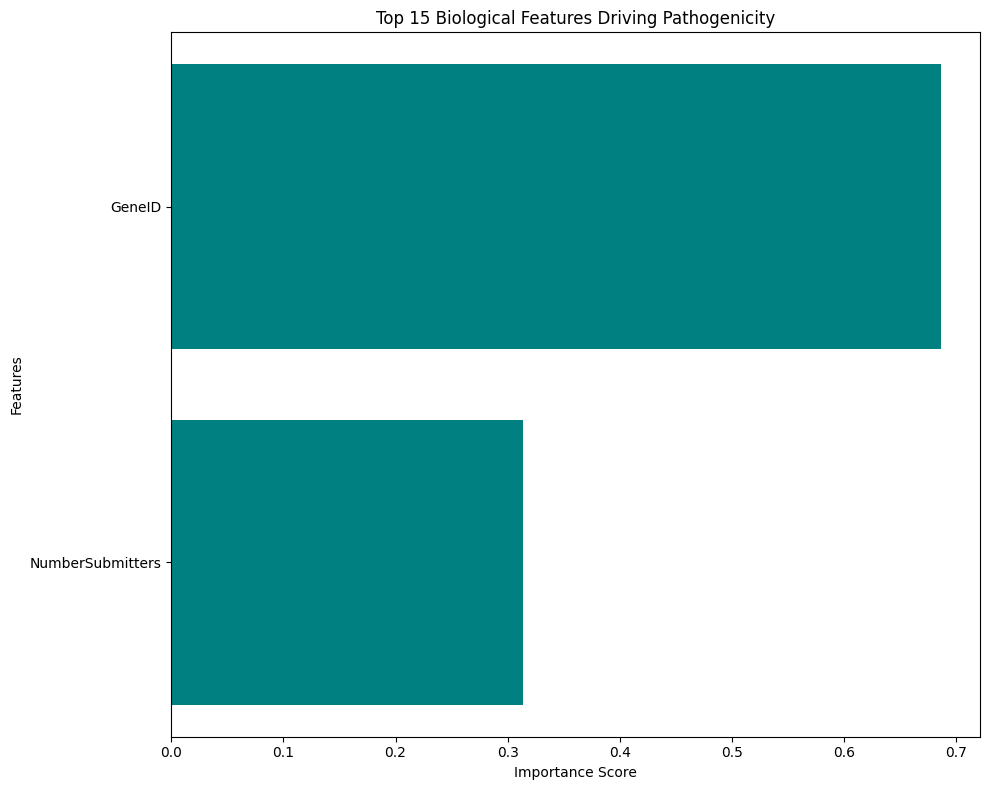

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract feature importances from your trained final_model
importances = final_model.feature_importances_
feature_names = X.columns  # Ensure this matches the columns you trained on

# 2. Create a DataFrame for easy sorting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 3. Plot Top 15 Features
top_15 = feat_imp_df.tail(15)

plt.figure(figsize=(10, 8))
plt.barh(top_15['Feature'], top_15['Importance'], color='teal')
plt.title('Top 15 Biological Features Driving Pathogenicity')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()